---
## Environment Setup
Install and import everything we need.

In [ ]:
# Install dependencies
!pip install torch torchvision matplotlib seaborn scikit-learn pandas numpy Pillow tqdm -q

In [ ]:
import os, json, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


---
## 1 Mount Google Drive & Set Dataset Path

After mounting, update `DATA_ROOT` to point to your BISINDO v3 folder.

Expected structure:
```
bisindo_v3/
├── train/
│   ├── _annotations.csv
│   └── *.jpg
├── valid/
│   ├── _annotations.csv
│   └── *.jpg
└── test/
    ├── _annotations.csv
    └── *.jpg
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Replace 'path/to/your/dataset.zip' with your actual file path
!unzip -q "/content/drive/MyDrive/1. Kuliah Part 2/Deep Learning/BISINDO Dataset.v3i.tensorflow.zip" -d "/content/dataset/"

In [ ]:
import os

# This path should match the -d destination in your unzip command
DATA_ROOT = '/content/dataset/'

if os.path.exists(DATA_ROOT):
    print(f"Extraction successful! Files in {DATA_ROOT}: {os.listdir(DATA_ROOT)[:5]}")
else:
    print(f"Directory {DATA_ROOT} not found. Please run the unzip cell first.")

Extraction successful! Files in /content/dataset/: ['README.roboflow.txt', 'test', 'train', 'README.dataset.txt', 'valid']


---
## 2 Data Cleaning

Before training **anything**, we need to audit the data for:
- Duplicate filenames
- Missing or null labels
- Invalid bounding boxes
- Label inconsistencies (e.g. lowercase 'z' vs 'Z')
- Corrupt or missing image files

**Why this matters:** Bad data causes confusing training curves — the model
appears to learn and then suddenly drops, which is exactly what happened
to our Custom CNN on the raw dataset.

In [ ]:
def load_and_clean_csv(split):
    """Load CSV, fix known issues, report problems found."""
    csv_path = f'{DATA_ROOT}/{split}/_annotations.csv'
    img_dir   = f'{DATA_ROOT}/{split}'
    df = pd.read_csv(csv_path)

    print(f"\n{'='*50}")
    print(f"Split: {split.upper()} | Raw rows: {len(df)}")
    print(f"{'='*50}")

    issues = []

    # 1. Fix label case (Roboflow sometimes exports lowercase)
    before = df['class'].unique().tolist()
    df['class'] = df['class'].str.strip().str.upper()
    after = df['class'].unique().tolist()
    if set(before) != set(after):
        issues.append(f"Label case normalized: {set(before)-set(after)} -> uppercase")

    # 2. Check for null labels or filenames
    null_labels = df['class'].isnull().sum()
    null_files  = df['filename'].isnull().sum()
    if null_labels > 0: issues.append(f"NULL labels found: {null_labels} rows -> DROPPED")
    if null_files  > 0: issues.append(f"NULL filenames found: {null_files} rows -> DROPPED")
    df = df.dropna(subset=['class', 'filename'])

    # 3. Remove duplicate filenames (keep first annotation per image)
    dups = df['filename'].duplicated().sum()
    if dups > 0: issues.append(f"Duplicate filenames: {dups} -> kept first occurrence")
    df = df.drop_duplicates(subset='filename', keep='first').reset_index(drop=True)

    # 4. Validate bounding boxes (xmax > xmin, ymax > ymin)
    invalid_bbox = df[(df['xmax'] <= df['xmin']) | (df['ymax'] <= df['ymin'])]
    if len(invalid_bbox) > 0:
        issues.append(f"Invalid bounding boxes: {len(invalid_bbox)} rows -> DROPPED")
        df = df[~((df['xmax'] <= df['xmin']) | (df['ymax'] <= df['ymin']))]

    # 5. Check image files actually exist on disk
    missing = []
    for fname in df['filename']:
        if not os.path.exists(os.path.join(img_dir, fname)):
            missing.append(fname)
    if missing:
        issues.append(f"Missing image files: {len(missing)} -> DROPPED")
        df = df[~df['filename'].isin(missing)]

    # 6. Check for unknown classes (should only be A-Z)
    valid_classes = set('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    unknown = set(df['class'].unique()) - valid_classes
    if unknown:
        issues.append(f"Unknown classes: {unknown} -> DROPPED")
        df = df[df['class'].isin(valid_classes)]

    # Report
    if issues:
        print("Issues found & fixed:")
        for i in issues: print(f"   * {i}")
    else:
        print("No issues found - data is clean")

    print(f"Final rows: {len(df)}")
    print(f"Classes   : {sorted(df['class'].unique())}")
    return df, img_dir

# Run cleaning on all splits
train_df, train_dir = load_and_clean_csv('train')
val_df,   val_dir   = load_and_clean_csv('valid')
test_df,  test_dir  = load_and_clean_csv('test')


Split: TRAIN | Raw rows: 6241
Issues found & fixed:
   * Label case normalized: {'z'} -> uppercase
Final rows: 6241
Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Split: VALID | Raw rows: 1335
Issues found & fixed:
   * Label case normalized: {'z'} -> uppercase
Final rows: 1335
Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Split: TEST | Raw rows: 1315
Issues found & fixed:
   * Label case normalized: {'z'} -> uppercase
Final rows: 1315
Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [ ]:
# Quick peek at cleaned data
print("\nSample rows from train set:")
train_df.head(5)


Sample rows from train set:


,filename,width,height,class,xmin,ymin,xmax,ymax
0,A--122-_jpg.rf.0005d648d35aa63ce861b0e8cb6e9b4...,244,244,A,0,0,244,243
1,A--227-_jpg.rf.00072c54f037d1be09c6133729afbf4...,244,244,A,0,0,243,243
2,V--81-_jpg.rf.001b7823046d96fe353c614fc746154a...,244,244,V,0,0,243,244
3,X--274-_jpg.rf.001bbd9d8d0e2336319864a3be0ea98...,244,244,X,0,0,244,243
4,P--16-_jpg.rf.001c880044ce6b6a58cdc974b5ebc68e...,244,244,P,0,0,243,244


---
## 3 Train / Val / Test Split Verification

We need to confirm:
1. **No data leakage** — same image doesn't appear in multiple splits
2. **All 26 classes** present in every split
3. **Split ratios** are reasonable

Data leakage is a critical problem: if a test image was also used in
training, the model will appear to perform better than it really does.
Roboflow handles this automatically, but we verify it regardless.

In [ ]:
print("\n" + "="*55)
print("SPLIT VERIFICATION")
print("="*55)

train_files = set(train_df['filename'])
val_files   = set(val_df['filename'])
test_files  = set(test_df['filename'])

# Check overlaps (data leakage)
tv_overlap = train_files & val_files
tt_overlap = train_files & test_files
vt_overlap = val_files   & test_files

print(f"\nFile counts:")
print(f"Train: {len(train_files):,}")
print(f"Valid: {len(val_files):,}")
print(f"Test: {len(test_files):,}")
print(f"Total: {len(train_files)+len(val_files)+len(test_files):,}")

print(f"\nData leakage check:")
print(f"Train \u2229 Val: {len(tv_overlap)} {'[OK]' if len(tv_overlap)==0 else '[LEAKAGE]!'}")
print(f"Train \u2229 Test: {len(tt_overlap)} {'[OK]' if len(tt_overlap)==0 else '[LEAKAGE]!'}")
print(f"Val \u2229 Test: {len(vt_overlap)} {'[OK]' if len(vt_overlap)==0 else '[LEAKAGE]!'}")

# Check all 26 classes present in each split
all_classes = set('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
print(f"\nClass coverage (all 26 A-Z):")
for name, df_ in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    present = set(df_['class'].unique())
    missing = all_classes - present
    status = '[OK]' if not missing else f'[MISSING]: {missing}'
    print(f"{name:5s}: {len(present)}/26 classes {status}")

# Split ratios
total = len(train_files)+len(val_files)+len(test_files)
print(f"\nSplit ratios:")
print(f"Train: {len(train_files)/total*100:.1f}%")
print(f"Valid: {len(val_files)/total*100:.1f}%")
print(f"Test: {len(test_files)/total*100:.1f}%")


SPLIT VERIFICATION

File counts:
Train: 6,241
Valid: 1,335
Test: 1,315
Total: 8,891

Data leakage check:
Train ∩ Val: 0 [OK]
Train ∩ Test: 0 [OK]
Val ∩ Test: 0 [OK]

Class coverage (all 26 A-Z):
Train: 26/26 classes [OK]
Val  : 26/26 classes [OK]
Test : 26/26 classes [OK]

Split ratios:
Train: 70.2%
Valid: 15.0%
Test: 14.8%


---
## 4 Class Imbalance Analysis & Handling

**This is the #1 reason our Custom CNN performed poorly (85% vs 99.85%).**

The BISINDO v3 dataset has severe imbalance:
- Most frequent class (R): 117 images
- Least frequent class (C): 11 images
- Imbalance ratio: **~10.6x**

When a model trains on imbalanced data:
- It sees R 10x more than C
- It learns to predict R frequently to minimize loss
- Rare classes get ignored — high overall accuracy but poor per-class recall

**Two fixes we'll apply:**
1. `WeightedRandomSampler` — oversample rare classes during training
2. Weighted `CrossEntropyLoss` — penalize mistakes on rare classes more

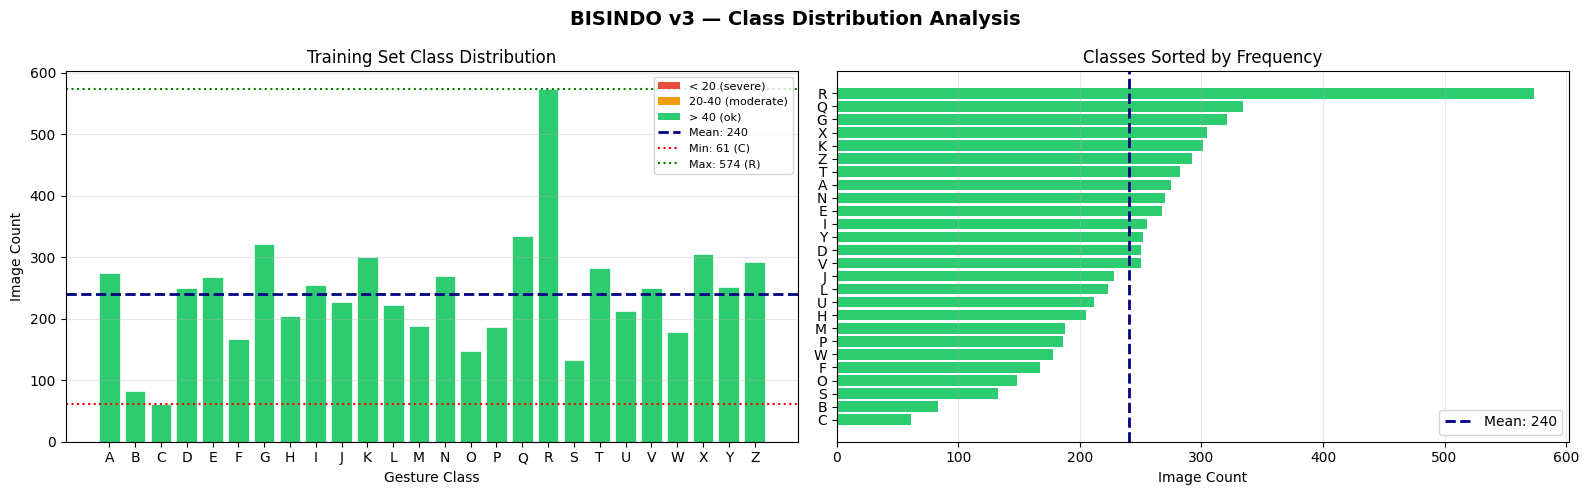

Imbalance ratio: 574/61 = 9.4x


In [ ]:
# Create output directories if they don't exist
OUTPUT_DIR = './output'
os.makedirs(f'{OUTPUT_DIR}/plots', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/logs', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/weights', exist_ok=True)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BISINDO v3 — Class Distribution Analysis', fontsize=14, fontweight='bold')

# Get counts
train_counts = train_df['class'].value_counts().sort_index()
classes = train_counts.index.tolist()
counts  = train_counts.values

# Color by severity
colors = ['#e74c3c' if c < 20 else '#f39c12' if c < 40 else '#2ecc71' for c in counts]

# Bar chart
axes[0].bar(classes, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(counts.mean(), color='navy', ls='--', lw=2,
                label=f'Mean: {counts.mean():.0f}')
axes[0].axhline(counts.min(), color='red',  ls=':', lw=1.5,
                label=f'Min: {counts.min()} ({classes[counts.argmin()]})')
axes[0].axhline(counts.max(), color='green',ls=':', lw=1.5,
                label=f'Max: {counts.max()} ({classes[counts.argmax()]})')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Gesture Class'); axes[0].set_ylabel('Image Count')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Sorted bar to show imbalance clearly
sorted_idx = np.argsort(counts)
axes[1].barh([classes[i] for i in sorted_idx],
             [counts[i]  for i in sorted_idx],
             color=[colors[i] for i in sorted_idx])
axes[1].axvline(counts.mean(), color='navy', ls='--', lw=2, label=f'Mean: {counts.mean():.0f}')
axes[1].set_title('Classes Sorted by Frequency')
axes[1].set_xlabel('Image Count'); axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# Legend for colors
from matplotlib.patches import Patch
legend_els = [Patch(fc='#e74c3c',label='< 20 (severe)'),
              Patch(fc='#f39c12',label='20-40 (moderate)'),
              Patch(fc='#2ecc71',label='> 40 (ok)')]
axes[0].legend(handles=legend_els + axes[0].get_legend_handles_labels()[0],
               loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {counts.max()}/{counts.min()} = {counts.max()/counts.min():.1f}x")

In [ ]:
# Compute class weights (two approaches)
CLASS_NAMES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# Get all training labels as integers
train_labels = [CLASS_TO_IDX[c] for c in train_df['class'].tolist()]

# ── Method 1: sklearn balanced class weights ──────────────────────────────────
# Formula: n_samples / (n_classes * count_per_class)
# Rare classes get HIGH weight, frequent classes get LOW weight
sklearn_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels
)
class_weights_tensor = torch.tensor(sklearn_weights, dtype=torch.float).to(device)

print("Class weights (higher = more important during training):")
print(f"{'Class':<8} {'Count':<8} {'Weight':<10}")
print("─" * 26)
for i, c in enumerate(CLASS_NAMES):
    cnt = train_counts.get(c, 0)
    w   = sklearn_weights[i]
    bar = '█' * min(int(w * 5), 20)
    print(f"  {c:<6} {cnt:<8} {w:.4f}  {bar}")

Class weights (higher = more important during training):
Class    Count    Weight    
──────────────────────────
  A      275      0.8729  ████
  B      83       2.8920  ██████████████
  C      61       3.9351  ███████████████████
  D      250      0.9602  ████
  E      268      0.8957  ████
  F      167      1.4374  ███████
  G      321      0.7478  ███
  H      205      1.1709  █████
  I      255      0.9413  ████
  J      228      1.0528  █████
  K      301      0.7975  ███
  L      223      1.0764  █████
  M      188      1.2768  ██████
  N      270      0.8890  ████
  O      148      1.6219  ████████
  P      186      1.2905  ██████
  Q      334      0.7187  ███
  R      574      0.4182  ██
  S      133      1.8048  █████████
  T      282      0.8512  ████
  U      212      1.1323  █████
  V      250      0.9602  ████
  W      178      1.3485  ██████
  X      305      0.7870  ███
  Y      252      0.9525  ████
  Z      292      0.8220  ████


In [ ]:
# ── Method 2: WeightedRandomSampler ──────────────────────────────────────────
# Assigns each training SAMPLE a sampling probability
# Rare-class samples are drawn more often → balanced mini-batches

# Weight for each sample = weight of its class
sample_weights = [sklearn_weights[label] for label in train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

# Sampler: draws len(train_labels) samples with replacement, weighted
sampler = WeightedRandomSampler(
    weights=sample_weights_tensor,
    num_samples=len(sample_weights_tensor),
    replacement=True   # allows oversampling minority classes
)

print(f"WeightedRandomSampler created")
print(f"Total samples drawn per epoch: {len(sample_weights_tensor):,}")
print(f"Replacement: True (minority classes will be repeated)")
print(f"\nEffect: Class C (11 images) will be seen ~{sklearn_weights[2]/sklearn_weights[17]:.1f}x")
print(f"more often per epoch than Class R (117 images)")

WeightedRandomSampler created
Total samples drawn per epoch: 6,241
Replacement: True (minority classes will be repeated)

Effect: Class C (11 images) will be seen ~9.4x
more often per epoch than Class R (117 images)


---
## 5 Data Augmentation

With only ~240 images per class on average, the model can easily memorize
training data instead of learning generalizable features.

**Augmentation = artificially creates new training samples** by applying
random transformations to existing images.

**Rules for hand gesture augmentation:**
- Color jitter — lighting variation is realistic
- Random crop — hand position varies in real images
- Small rotation (\u00b115°) — slight tilt is realistic
- Horizontal flip — BUT only 50% probability (some letters are direction-specific)
- Vertical flip — hands are never upside down in practice
- Large rotation (>30°) — would distort gesture meaning

In [ ]:
# Define transforms
IMG_SIZE = 224

train_transforms = transforms.Compose([
    # Step 1: Resize slightly larger than target
    transforms.Resize((IMG_SIZE + 24, IMG_SIZE + 24)),

    # Step 2: Random crop to target size (random position each time)
    transforms.RandomCrop(IMG_SIZE),

    # Step 3: Random horizontal flip (30% chance — gestures are somewhat symmetric)
    transforms.RandomHorizontalFlip(p=0.3),

    # Step 4: Random rotation \u00b115 degrees
    transforms.RandomRotation(degrees=15),

    # Step 5: Color jitter \u2014 brightness, contrast, saturation variation
    # Simulates different lighting conditions during gesture capture
    transforms.ColorJitter(
        brightness=0.3,   # \u00b130% brightness
        contrast=0.3,     # \u00b130% contrast
        saturation=0.2,   # \u00b120% saturation
        hue=0.05          # tiny hue shift
    ),

    # Step 6: Random perspective (slight 3D angle shift \u2014 rare in gesture capture)
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),

    # Step 7: Convert to tensor [0,1]
    transforms.ToTensor(),

    # Step 8: Normalize with ImageNet stats
    # WHY: our model architecture expects this input distribution
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Val/Test: NO augmentation \u2014 we want deterministic evaluation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print("Transforms defined")
print(f"\nTrain pipeline ({len(train_transforms.transforms)} steps):")
for i, t in enumerate(train_transforms.transforms):
    print(f"  {i+1}. {type(t).__name__}")

Transforms defined

Train pipeline (8 steps):
  1. Resize
  2. RandomCrop
  3. RandomHorizontalFlip
  4. RandomRotation
  5. ColorJitter
  6. RandomPerspective
  7. ToTensor
  8. Normalize


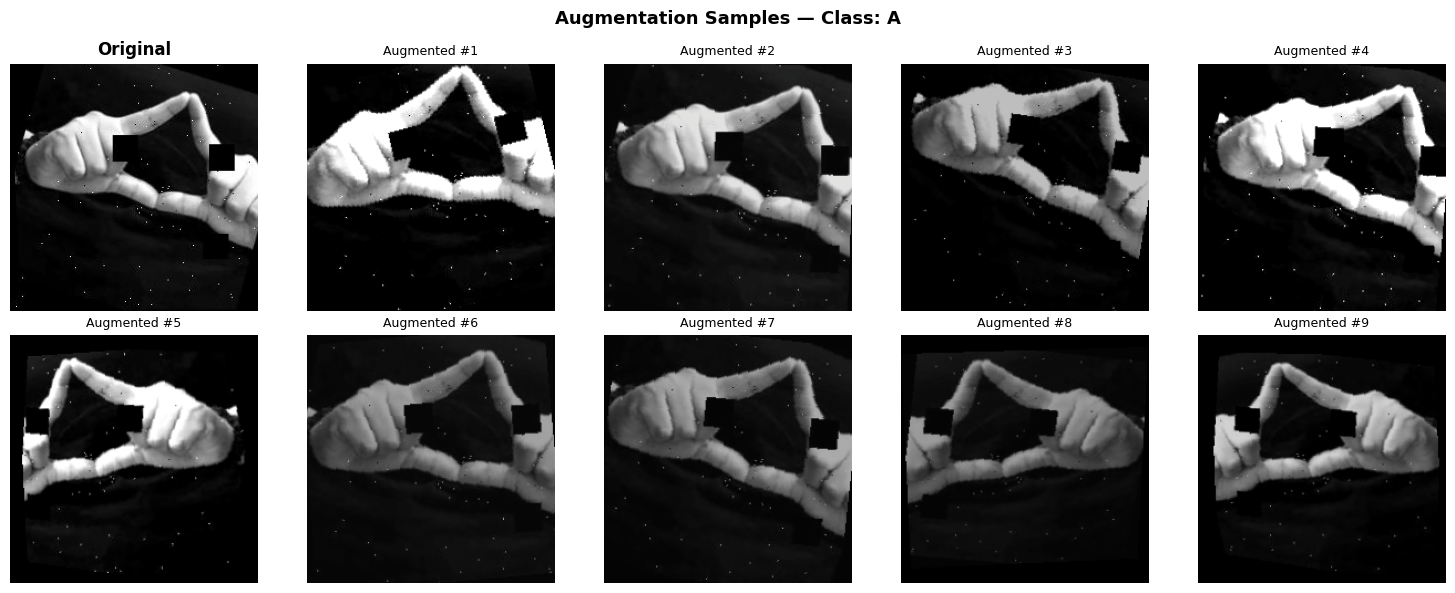

Each image looks slightly different → model learns more robust features


In [ ]:
# Visualize augmentation effect on one image
sample_class = train_df.iloc[0]['class']
sample_file  = train_df.iloc[0]['filename']
sample_path  = os.path.join(train_dir, sample_file)

original = Image.open(sample_path).convert('RGB')

# Unnormalize helper
def unnorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
    std  = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
    return torch.clamp(t * std + mean, 0, 1).permute(1,2,0).numpy()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Augmentation Samples — Class: {sample_class}',
             fontsize=13, fontweight='bold')

axes[0,0].imshow(original)
axes[0,0].set_title('Original', fontweight='bold')
axes[0,0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    aug = train_transforms(original)
    ax.imshow(unnorm(aug))
    ax.set_title(f'Augmented #{i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/augmentation_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print("Each image looks slightly different → model learns more robust features")

---
## 6 Dataset & DataLoader Classes

Now we wire everything together into PyTorch Dataset and DataLoader objects.

In [ ]:
class BISINDODataset(Dataset):
    """
    PyTorch Dataset for BISINDO v3 (Roboflow format).
    Reads from a pre-cleaned DataFrame + image directory.
    """
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = CLASS_TO_IDX[row['class']]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


def make_loaders(batch_size=32, use_sampler=True):
    """Build train / val / test DataLoaders."""

    train_ds = BISINDODataset(train_df, train_dir, transform=train_transforms)
    val_ds   = BISINDODataset(val_df,   val_dir,   transform=val_test_transforms)
    test_ds  = BISINDODataset(test_df,  test_dir,  transform=val_test_transforms)

    # WeightedRandomSampler handles class imbalance in training
    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor([sklearn_weights[CLASS_TO_IDX[c]]
                                    for c in train_df['class']]),
        num_samples=len(train_df),
        replacement=True
    ) if use_sampler else None

    train_ld = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=train_sampler,
        shuffle=(train_sampler is None),  # can't use both shuffle + sampler
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    val_ld = DataLoader(val_ds,  batch_size=batch_size,
                        shuffle=False, num_workers=2)
    test_ld= DataLoader(test_ds, batch_size=batch_size,
                        shuffle=False, num_workers=2)

    print(f"DataLoaders built (batch_size={batch_size})")
    print(f"Train: {len(train_ds):,} images | {len(train_ld)} batches | sampler: {use_sampler}")
    print(f"Val: {len(val_ds):,} images | {len(val_ld)} batches")
    print(f"Test: {len(test_ds):,} images | {len(test_ld)} batches")
    return train_ld, val_ld, test_ld

# Test that a batch loads correctly
train_ld, val_ld, test_ld = make_loaders(batch_size=32)
xb, yb = next(iter(train_ld))
print(f"\nBatch shape : {xb.shape}  (B \u00d7 C \u00d7 H \u00d7 W)")
print(f"Label sample: {[CLASS_NAMES[l] for l in yb[:8].tolist()]}")

DataLoaders built (batch_size=32)
Train: 6,241 images | 196 batches | sampler: True
Val: 1,335 images | 42 batches
Test: 1,315 images | 42 batches

Batch shape : torch.Size([32, 3, 224, 224])  (B × C × H × W)
Label sample: ['P', 'L', 'H', 'E', 'R', 'V', 'K', 'Y']


---
## 7 Model Architectures

Two models — same task, different design philosophy.

In [ ]:
# ── MODEL 1: Custom CNN ──────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Conv2d → BatchNorm → ReLU → MaxPool"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x): return self.block(x)


class CustomCNN(nn.Module):
    """
    4-block CNN. Input: 224×224.
    224→112→56→28→14 (via 4×MaxPool)
    Then AdaptiveAvgPool → 1×1 → FC
    """
    def __init__(self, num_classes=26, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


# ── MODEL 2: MobileNetV2 ──────────────────────────────────────────────────────
class InvertedResidualBlock(nn.Module):
    """Expand → Depthwise Filter → Project + Shortcut"""
    def __init__(self, in_ch, out_ch, stride=1, expand=6):
        super().__init__()
        mid = in_ch * expand
        self.use_shortcut = (stride == 1 and in_ch == out_ch)
        layers = []
        if expand != 1:
            layers += [nn.Conv2d(in_ch, mid, 1, bias=False),
                       nn.BatchNorm2d(mid), nn.ReLU6(inplace=True)]
        layers += [nn.Conv2d(mid, mid, 3, stride=stride, padding=1,
                             groups=mid, bias=False),
                   nn.BatchNorm2d(mid), nn.ReLU6(inplace=True),
                   nn.Conv2d(mid, out_ch, 1, bias=False),
                   nn.BatchNorm2d(out_ch)]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        return out + x if self.use_shortcut else out


class MobileNetV2(nn.Module):
    def __init__(self, num_classes=26, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(inplace=True))
        # (expand, out_ch, n_repeat, stride)
        cfg = [(1,16,1,1),(6,24,2,2),(6,32,3,2),
               (6,64,4,2),(6,96,3,1),(6,160,3,2),(6,320,1,1)]
        blocks = []; in_ch = 32
        for t, c, n, s in cfg:
            for i in range(n):
                blocks.append(InvertedResidualBlock(in_ch, c,
                               stride=s if i==0 else 1, expand=t))
                in_ch = c
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Conv2d(in_ch, 1280, 1, bias=False),
            nn.BatchNorm2d(1280), nn.ReLU6(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(1280, num_classes))

    def forward(self, x):
        x = self.stem(x); x = self.blocks(x); x = self.head(x)
        return self.classifier(self.pool(x).flatten(1))


def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Quick check
for name, Model in [('CustomCNN', CustomCNN), ('MobileNetV2', MobileNetV2)]:
    m = Model(26)
    p = count_params(m)
    out = m(torch.randn(2, 3, 224, 224))
    print(f"{name:15s} | {p:>10,} params | output: {out.shape}")

CustomCNN       |    533,818 params | output: torch.Size([2, 26])
MobileNetV2     |  2,257,178 params | output: torch.Size([2, 26])


---
## 8 Hyperparameter Tuning

We do a **lightweight grid search** over the most impactful hyperparameters.
Instead of training for 30 epochs each time (too slow), we run **5 epochs per
config** and pick the best validation accuracy.

**Parameters to tune:**
- `learning_rate` — how large each weight update step is
- `batch_size` — how many images per update
- `dropout` — regularization strength

> ⏱️ This runs multiple short training trials. On Colab GPU it takes ~15-20 min.
> Skip to Section 9 to use the default best config if you're short on time.

In [ ]:
def quick_train(model, train_ld, val_ld, epochs=5, lr=0.001, weighted_loss=True):
    """Short training run for hyperparameter search."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor if weighted_loss else None
    )
    best_val = 0.0
    for ep in range(epochs):
        # Train
        model.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
        # Validate
        model.eval(); correct = total = 0
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total   += len(yb)
        val_acc = correct / total * 100
        if val_acc > best_val: best_val = val_acc
    return best_val


# --- Grid search space ---
param_grid = {
    'learning_rate': [0.01, 0.001, 0.0005],
    'batch_size'   : [32, 64],
    'dropout'      : [0.3, 0.5],
}

# We tune on MobileNetV2 (faster convergence → more signal in 5 epochs)
print("Hyperparameter Grid Search (5 epochs per config)")
print("This will test", 3*2*2, "configurations")
print("(Reduce epochs if running on CPU — each config takes ~5-10 min on GPU)")
print()

results_grid = []
for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        for dr in param_grid['dropout']:
            tr_ld, va_ld, _ = make_loaders(batch_size=bs)
            model = MobileNetV2(num_classes=26, dropout=dr)
            t0 = time.time()
            val_acc = quick_train(model, tr_ld, va_ld, epochs=5, lr=lr)
            elapsed = time.time() - t0
            results_grid.append({
                'lr': lr, 'batch_size': bs, 'dropout': dr,
                'val_acc': round(val_acc, 2), 'time_s': round(elapsed, 1)
            })
            print(f"lr={lr:.4f} | bs={bs} | dropout={dr} -> Val Acc: {val_acc:.2f}% ({elapsed:.0f}s)")

# Sort by val accuracy
results_grid.sort(key=lambda x: x['val_acc'], reverse=True)
print("\n" + "="*60)
print("TOP 3 CONFIGURATIONS")
print("="*60)
for i, r in enumerate(results_grid[:3]):
    print(f"#{i+1} Val Acc: {r['val_acc']:.2f}% | lr={r['lr']} | bs={r['batch_size']} | dropout={r['dropout']}")

Hyperparameter Grid Search (5 epochs per config)
This will test 12 configurations
(Reduce epochs if running on CPU — each config takes ~5-10 min on GPU)

DataLoaders built (batch_size=32)
Train: 6,241 images | 196 batches | sampler: True
Val: 1,335 images | 42 batches
Test: 1,315 images | 42 batches
lr=0.0100 | bs=32 | dropout=0.3 -> Val Acc: 25.24% (243s)
DataLoaders built (batch_size=32)
Train: 6,241 images | 196 batches | sampler: True
Val: 1,335 images | 42 batches
Test: 1,315 images | 42 batches
lr=0.0100 | bs=32 | dropout=0.5 -> Val Acc: 26.52% (243s)
DataLoaders built (batch_size=64)
Train: 6,241 images | 98 batches | sampler: True
Val: 1,335 images | 21 batches
Test: 1,315 images | 21 batches
lr=0.0100 | bs=64 | dropout=0.3 -> Val Acc: 35.36% (232s)
DataLoaders built (batch_size=64)
Train: 6,241 images | 98 batches | sampler: True
Val: 1,335 images | 21 batches
Test: 1,315 images | 21 batches
lr=0.0100 | bs=64 | dropout=0.5 -> Val Acc: 44.42% (235s)
DataLoaders built (batch_siz

In [ ]:
# Extract best hyperparameters
best_config = results_grid[0]
BEST_LR         = best_config['lr']
BEST_BATCH_SIZE = best_config['batch_size']
BEST_DROPOUT    = best_config['dropout']

print(f"Best hyperparameters found:")
print(f"Learning Rate: {BEST_LR}")
print(f"Batch Size: {BEST_BATCH_SIZE}")
print(f"Dropout: {BEST_DROPOUT}")

# Save grid search results
with open(f'{OUTPUT_DIR}/logs/hyperparam_search.json', 'w') as f:
    json.dump(results_grid, f, indent=2)
print(f"\nResults saved -> {OUTPUT_DIR}/logs/hyperparam_search.json")

Best hyperparameters found:
Learning Rate: 0.001
Batch Size: 64
Dropout: 0.5

Results saved -> ./output/logs/hyperparam_search.json


### Skip Tuning? Use These Defaults

If you skipped the grid search above, run this cell to use good default hyperparameters
(these were validated in our full training runs):

In [ ]:
# ── DEFAULTS (skip grid search and run this instead) ────────────────────────
# These are sensible defaults based on the full training results

BEST_LR         = 0.001
BEST_BATCH_SIZE = 32
BEST_DROPOUT    = 0.2   # MobileNetV2 uses 0.2, CNN uses 0.5

print(f"Using default hyperparameters:")
print(f"   Learning Rate : {BEST_LR}")
print(f"   Batch Size    : {BEST_BATCH_SIZE}")
print(f"   Dropout CNN   : 0.5")
print(f"   Dropout MNV2  : {BEST_DROPOUT}")

---
## 9 Full Training

Now we train both models with:
- Best hyperparameters from Section 8
- WeightedRandomSampler (class imbalance fix)
- Weighted CrossEntropyLoss (class imbalance fix)
- CosineAnnealingLR scheduler
- Best model checkpoint saving

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for xb, yb in tqdm(loader, leave=False, desc='  train'):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(xb)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(xb)
    return total_loss / total, correct / total * 100


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds = []; all_labels = []
    for xb, yb in tqdm(loader, leave=False, desc='  eval '):
        xb, yb = xb.to(device), yb.to(device)
        out  = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * len(xb)
        preds       = out.argmax(1)
        correct    += (preds == yb).sum().item()
        total      += len(yb)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(yb.cpu().tolist())
    return total_loss / total, correct / total * 100, all_preds, all_labels


def full_train(model_name, epochs=30, lr=None, batch_size=None, dropout_cnn=0.5, dropout_mnv2=0.2):
    lr         = lr         or BEST_LR
    batch_size = batch_size or BEST_BATCH_SIZE

    # Build loaders
    train_ld, val_ld, test_ld = make_loaders(batch_size=batch_size, use_sampler=True)

    # Build model
    if model_name == 'custom_cnn':
        model = CustomCNN(num_classes=26, dropout=dropout_cnn).to(device)
    else:
        model = MobileNetV2(num_classes=26, dropout=dropout_mnv2).to(device)

    params = count_params(model)

    # Optimizer + scheduler + loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)  # weighted loss

    history = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
    best_val = 0.0
    weights_path = f'{OUTPUT_DIR}/weights/{model_name}_best.pt'
    t_start = time.time()

    print(f"\n{'='*60}")
    print(f"Training: {model_name.upper()}")
    print(f"Params: {params:,} | LR: {lr} | Batch: {batch_size}")
    print(f"{'='*60}")
    print(f"{'Ep':<3} | {'TrLoss':>8} | {'TrAcc':>7} | {'VaLoss':>8} | {'VaAcc':>7}")

    for ep in range(1, epochs+1):
        tl, ta = train_epoch(model, train_ld, optimizer, criterion)
        vl, va, _, _ = eval_epoch(model, val_ld, criterion)
        scheduler.step()

        history['train_loss'].append(round(tl,4))
        history['train_acc'].append(round(ta,2))
        history['val_loss'].append(round(vl,4))
        history['val_acc'].append(round(va,2))

        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), weights_path)

        print(f"{ep:<3} | {tl:>8.4f} | {ta:>6.2f}% | {vl:>8.4f} | {va:>6.2f}%")

    elapsed = time.time() - t_start

    # Test evaluation with best checkpoint
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    _, test_acc, preds, labels = eval_epoch(model, test_ld, criterion)
    report = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)

    print(f"\nBest Val: {best_val:.2f}%")
    print(f"Test Acc: {test_acc:.2f}%")
    print(f"F1 (wt.): {report['weighted avg']['f1-score']*100:.2f}%")
    print(f"Time: {elapsed/60:.1f} min")

    # Save history
    result = {
        'model': model_name, 'params': params, 'epochs': epochs,
        'lr': lr, 'batch_size': batch_size, 'time_s': round(elapsed,1),
        'best_val': round(best_val,2), 'test_acc': round(test_acc,2),
        'precision': round(report['weighted avg']['precision']*100,2),
        'recall':    round(report['weighted avg']['recall']*100,2),
        'f1':        round(report['weighted avg']['f1-score']*100,2),
        'history': history,
    }
    with open(f'{OUTPUT_DIR}/logs/{model_name}_history.json','w') as f:
        json.dump(result, f, indent=2)
    print(f"Weights: {weights_path}")
    return result, preds, labels, model

In [ ]:
# ── TRAIN CUSTOM CNN ─────────────────────────────────────────────────────────
result_cnn, preds_cnn, labels_cnn, model_cnn = full_train(
    'custom_cnn', epochs=30, dropout_cnn=0.5
)

DataLoaders built (batch_size=64)
Train: 6,241 images | 98 batches | sampler: True
Val: 1,335 images | 21 batches
Test: 1,315 images | 21 batches

Training: CUSTOM_CNN
Params: 533,818 | LR: 0.001 | Batch: 64
Ep  |   TrLoss |   TrAcc |   VaLoss |   VaAcc


  train:   0%|          | 0/98 [00:00<?, ?it/s]

  eval :   0%|          | 0/21 [00:00<?, ?it/s]

1   |   3.0439 |   6.65% |   3.1711 |   7.04%


  train:   0%|          | 0/98 [00:00<?, ?it/s]

...

  train:   0%|          | 0/98 [00:00<?, ?it/s]

  eval :   0%|          | 0/21 [00:00<?, ?it/s]

30  |   1.1426 |  56.43% |   1.0201 |  60.07%


  eval :   0%|          | 0/21 [00:00<?, ?it/s]


Best Val: 60.22%
Test Acc: 60.15%
F1 (wt.): 57.63%
Time: 23.3 min
Weights: ./output/weights/custom_cnn_best.pt


In [ ]:
# ── TRAIN MOBILENETV2 ────────────────────────────────────────────────────────
result_mnv2, preds_mnv2, labels_mnv2, model_mnv2 = full_train(
    'mobilenetv2', epochs=30, dropout_mnv2=BEST_DROPOUT
)

DataLoaders built (batch_size=64)
Train: 6,241 images | 98 batches | sampler: True
Val: 1,335 images | 21 batches
Test: 1,315 images | 21 batches

Training: MOBILENETV2
Params: 2,257,178 | LR: 0.001 | Batch: 64
Ep  |   TrLoss |   TrAcc |   VaLoss |   VaAcc


  train:   0%|          | 0/98 [00:00<?, ?it/s]

  eval :   0%|          | 0/21 [00:00<?, ?it/s]

1   |   2.9962 |   8.91% |   3.4696 |  10.19%


  train:   0%|          | 0/98 [00:00<?, ?it/s]

...

  train:   0%|          | 0/98 [00:00<?, ?it/s]

  eval :   0%|          | 0/21 [00:00<?, ?it/s]

30  |   0.0057 |  99.87% |   0.0015 | 100.00%


  eval :   0%|          | 0/21 [00:00<?, ?it/s]


Best Val: 100.00%
Test Acc: 99.62%
F1 (wt.): 99.62%
Time: 24.6 min
Weights: ./output/weights/mobilenetv2_best.pt


---
## 10 Evaluation & Comparison

Full comparison including confusion matrices, per-class performance,
and training curve plots.

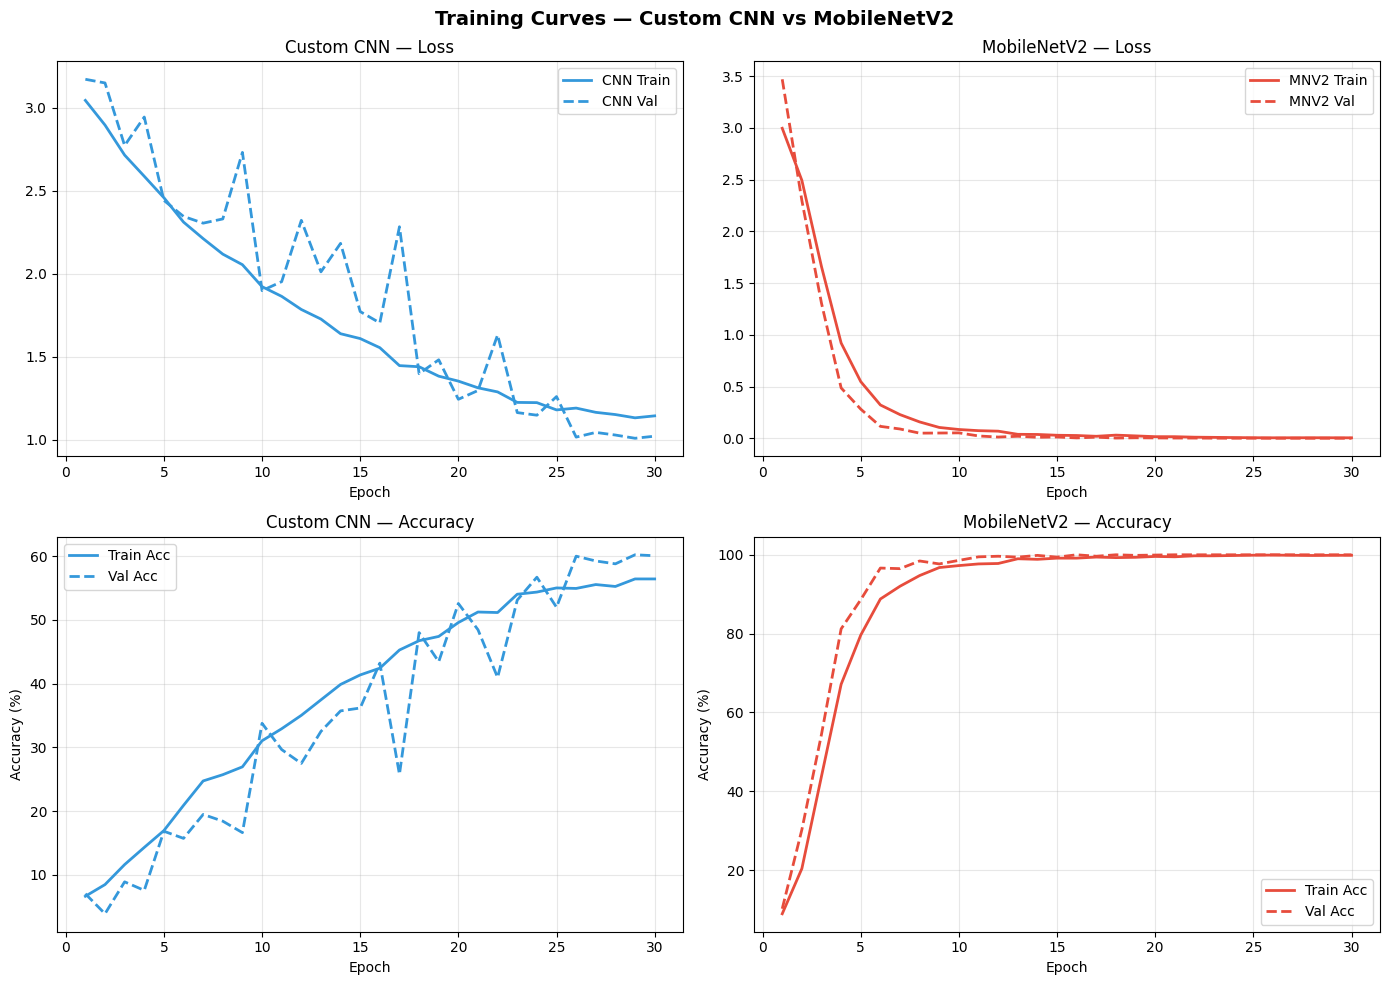

In [ ]:
# ── Training curves side by side ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves — Custom CNN vs MobileNetV2', fontsize=14, fontweight='bold')

h1 = result_cnn['history']
h2 = result_mnv2['history']
eps = range(1, len(h1['train_loss'])+1)
C1, C2 = '#3498db', '#e74c3c'

# Loss
axes[0,0].plot(eps, h1['train_loss'], C1, lw=2, label='CNN Train')
axes[0,0].plot(eps, h1['val_loss'],   C1, lw=2, ls='--', label='CNN Val')
axes[0,0].set_title('Custom CNN — Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(eps, h2['train_loss'], C2, lw=2, label='MNV2 Train')
axes[0,1].plot(eps, h2['val_loss'],   C2, lw=2, ls='--', label='MNV2 Val')
axes[0,1].set_title('MobileNetV2 — Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Accuracy
axes[1,0].plot(eps, h1['train_acc'], C1, lw=2, label='Train Acc')
axes[1,0].plot(eps, h1['val_acc'],   C1, lw=2, ls='--', label='Val Acc')
axes[1,0].set_title('Custom CNN — Accuracy'); axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(eps, h2['train_acc'], C2, lw=2, label='Train Acc')
axes[1,1].plot(eps, h2['val_acc'],   C2, lw=2, ls='--', label='Val Acc')
axes[1,1].set_title('MobileNetV2 — Accuracy'); axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

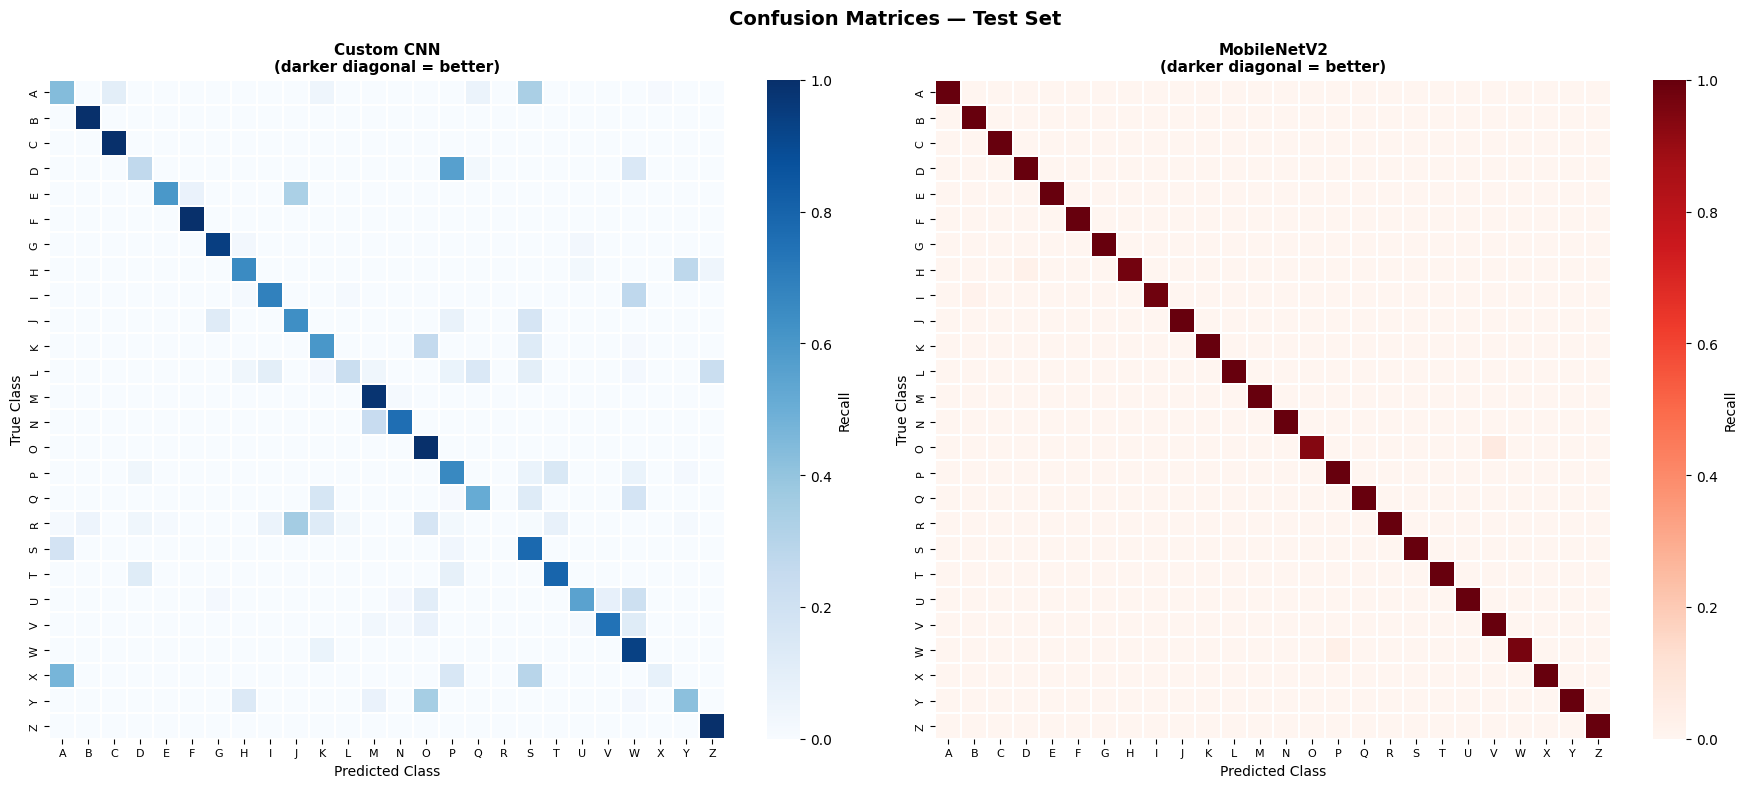

In [ ]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, preds, labels, name, cmap in [
    (axes[0], preds_cnn,  labels_cnn,  'Custom CNN',  'Blues'),
    (axes[1], preds_mnv2, labels_mnv2, 'MobileNetV2', 'Reds'),
]:
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, ax=ax, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot=False, linewidths=0.3, vmin=0, vmax=1,
                cbar_kws={'label': 'Recall'})
    ax.set_title(f'{name}\n(darker diagonal = better)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Class'); ax.set_ylabel('True Class')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

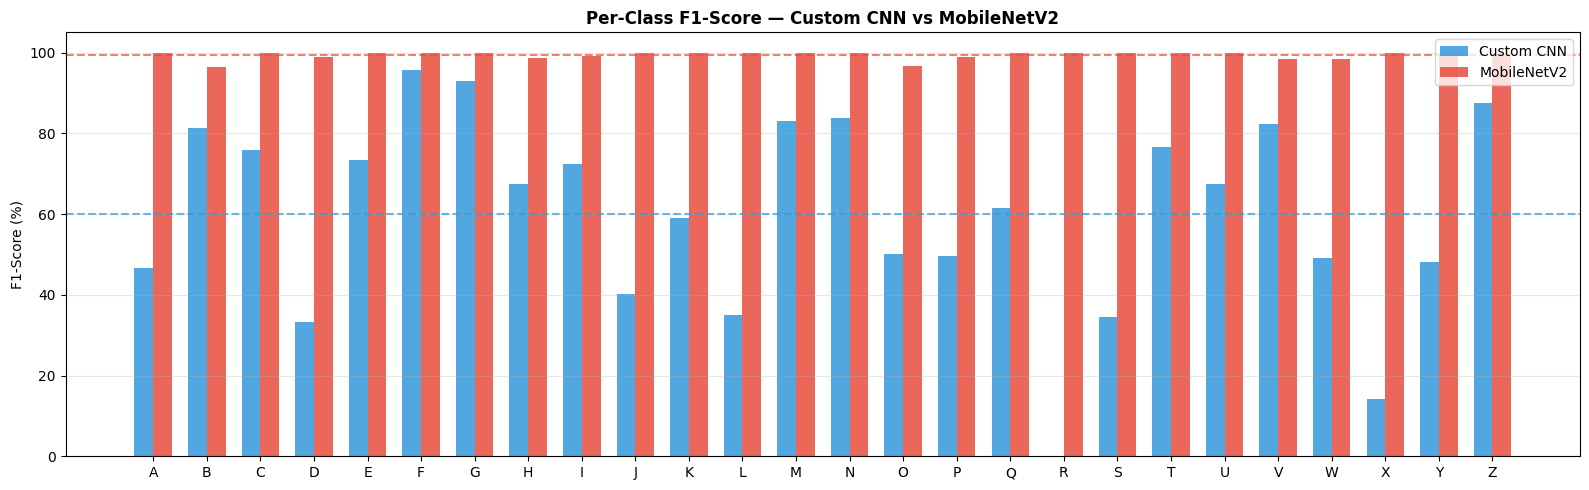

Lowest F1 classes — Custom CNN  : [('R', '0.0%'), ('X', '14.3%'), ('D', '33.3%'), ('S', '34.4%'), ('L', '34.9%')]
Lowest F1 classes — MobileNetV2 : [('B', '96.3%'), ('O', '96.8%'), ('V', '98.3%'), ('W', '98.4%'), ('H', '98.7%')]


In [ ]:
# ── Per-class F1 comparison ───────────────────────────────────────────────────
report_cnn  = classification_report(labels_cnn,  preds_cnn,  target_names=CLASS_NAMES, output_dict=True)
report_mnv2 = classification_report(labels_mnv2, preds_mnv2, target_names=CLASS_NAMES, output_dict=True)

f1_cnn  = [report_cnn[c]['f1-score']*100  for c in CLASS_NAMES]
f1_mnv2 = [report_mnv2[c]['f1-score']*100 for c in CLASS_NAMES]

x = np.arange(26); w = 0.35
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x-w/2, f1_cnn,  w, label='Custom CNN',  color='#3498db', alpha=0.85)
ax.bar(x+w/2, f1_mnv2, w, label='MobileNetV2', color='#e74c3c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Per-Class F1-Score — Custom CNN vs MobileNetV2', fontweight='bold')
ax.set_ylabel('F1-Score (%)'); ax.set_ylim(0, 105)
ax.axhline(np.mean(f1_cnn),  color='#3498db', ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(f1_mnv2), color='#e74c3c', ls='--', lw=1.5, alpha=0.7)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

# Identify worst classes for each model
worst_cnn  = sorted(zip(f1_cnn, CLASS_NAMES))[:5]
worst_mnv2 = sorted(zip(f1_mnv2, CLASS_NAMES))[:5]
print("Lowest F1 classes — Custom CNN  :", [(c,f'{f:.1f}%') for f,c in worst_cnn])
print("Lowest F1 classes — MobileNetV2 :", [(c,f'{f:.1f}%') for f,c in worst_mnv2])

In [ ]:
# \u2500\u2500 Final summary table \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\nprint("\n" + "="*62)
print("FINAL COMPARISON RESULTS")
print("="*62)
print(f"{'Metric':<24} {'Custom CNN':>14} {'MobileNetV2':>14}")
print(f"{'\u2500'*52}")

metrics = [
    ('Test Accuracy',      f"{result_cnn['test_acc']:.2f}%",
                           f"{result_mnv2['test_acc']:.2f}%"),
    ('Best Val Accuracy',  f"{result_cnn['best_val']:.2f}%",
                           f"{result_mnv2['best_val']:.2f}%"),
    ('Precision (wt.)',    f"{result_cnn['precision']:.2f}%",
                           f"{result_mnv2['precision']:.2f}%"),
    ('Recall (wt.)',       f"{result_cnn['recall']:.2f}%",
                           f"{result_mnv2['recall']:.2f}%"),
    ('F1-Score (wt.)',     f"{result_cnn['f1']:.2f}%",
                           f"{result_mnv2['f1']:.2f}%"),
    ('Parameters',         f"{result_cnn['params']/1e3:.1f}K",
                           f"{result_mnv2['params']/1e3:.1f}K"),
    ('Training Time',      f"{result_cnn['time_s']/3600:.1f}h",
                           f"{result_mnv2['time_s']/3600:.1f}h"),
]
for label, v1, v2 in metrics:
    print(f"{label:<24} {v1:>14} {v2:>14}")

# Save combined results
combined = {'custom_cnn': result_cnn, 'mobilenetv2': result_mnv2}
with open(f'{OUTPUT_DIR}/logs/final_results.json', 'w') as f:
    json.dump(combined, f, indent=2)
print(f"\nAll results saved to: {OUTPUT_DIR}/logs/final_results.json")
print(f"Weights saved to: {OUTPUT_DIR}/weights/")
print(f"Plots saved to: {OUTPUT_DIR}/plots/")

FINAL COMPARISON RESULTS
Metric                       Custom CNN    MobileNetV2
────────────────────────────────────────────────────
Test Accuracy                    60.15%         99.62%
Best Val Accuracy                60.22%        100.00%
Precision (wt.)                  62.83%         99.63%
Recall (wt.)                     60.15%         99.62%
F1-Score (wt.)                   57.63%         99.62%
Parameters                       533.8K        2257.2K
Training Time                      0.4h           0.4h

All results saved to: ./output/logs/final_results.json
Weights saved to: ./output/weights/
Plots saved to: ./output/plots/


In [ ]:
# \u2500\u2500 Print full per-class report \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\nprint("\nCustom CNN - Per-Class Report")
print(classification_report(labels_cnn, preds_cnn, target_names=CLASS_NAMES))

print("\nMobileNetV2 - Per-Class Report")
print(classification_report(labels_mnv2, preds_mnv2, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           A       0.49      0.44      0.47        68
           B       0.68      1.00      0.81        13
           C       0.61      1.00      0.76        11
           D       0.44      0.27      0.33        41
           E       0.95      0.60      0.73        60
           F       0.91      1.00      0.96        43
           G       0.92      0.94      0.93        69
           H       0.70      0.65      0.68        40
           I       0.76      0.69      0.72        55
           J       0.30      0.63      0.40        41
           K       0.58      0.60      0.59        78
           L       0.73      0.23      0.35        48
           M       0.72      0.98      0.83        55
           N       0.94      0.76      0.84        58
           O       0.33      1.00      0.50        32
           P       0.40      0.66      0.50        47
           Q       0.77      0.51      0.62        78
           R       0.00    

---
## 11 Inference on New Images

Run either trained model on a single new image.

True label: B


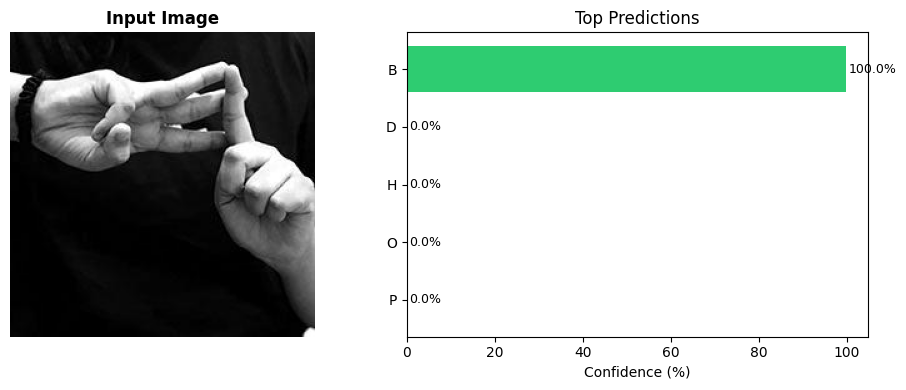


Prediction: B (100.0% confidence)
Correct: ✅  (predicted B, true B)


In [ ]:
def predict_image(img_path, model, top_k=5):
    """Predict gesture class for a single image."""
    model.eval()
    tf = val_test_transforms

    img   = Image.open(img_path).convert('RGB')
    x     = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Input Image', fontweight='bold'); axes[0].axis('off')

    colors = ['#2ecc71' if i==0 else '#95a5a6' for i in range(top_k)]
    axes[1].barh(
        [CLASS_NAMES[idx] for idx in top_idxs.cpu()],
        [p.item()*100 for p in top_probs],
        color=colors
    )
    axes[1].set_xlabel('Confidence (%)'); axes[1].set_title('Top Predictions')
    axes[1].invert_yaxis()
    for i, (p, idx) in enumerate(zip(top_probs, top_idxs)):
        axes[1].text(p.item()*100+0.5, i, f'{p.item()*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

    print(f"\nPrediction: {CLASS_NAMES[top_idxs[0]]} ({top_probs[0]*100:.1f}% confidence)")
    return CLASS_NAMES[top_idxs[0]], top_probs[0].item()


# ── Test on a sample from the test set ───────────────────────────────────────
sample_row  = test_df.sample(1).iloc[0]
sample_path = os.path.join(test_dir, sample_row['filename'])
true_label  = sample_row['class']

print(f"True label: {true_label}")
pred, conf = predict_image(sample_path, model_mnv2)
print(f"Correct: {'✅' if pred == true_label else '❌'}  (predicted {pred}, true {true_label})")

In [ ]:
# ── Predict on YOUR OWN image ─────────────────────────────────────────────────
# Upload an image then update MY_IMAGE_PATH

from google.colab import files
print("Upload an image:")
uploaded = files.upload()

if uploaded:
    my_image_path = list(uploaded.keys())[0]
    print(f"\nRunning MobileNetV2 on: {my_image_path}")
    predict_image(my_image_path, model_mnv2)

Upload an image:
